# Problem 1: Root Finding with the Secant Method

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WCC-Engineering/wcc-engineering-engr-240-spring-2026-pa3-roots-problems-ENGR240-Week3-Assignment/blob/main/problem1_secant_method.ipynb)

## Introduction

Finding the roots of nonlinear equations is a common task in engineering. In this problem, you'll implement the secant method, an efficient numerical technique for finding roots of equations in the form $f(x) = 0$. You'll also compare its performance with the bisection method.

## The Secant Method

The secant method is similar to Newton's method for finding roots, but it doesn't require calculating derivatives. Instead, it uses the slope between two points to approximate the derivative. This makes it particularly useful when the derivative is difficult or expensive to compute.

The iterative formula for the secant method is:

$$x_{i+1} = x_i - f(x_i) \frac{x_i - x_{i-1}}{f(x_i) - f(x_{i-1})}$$

where $x_i$ and $x_{i-1}$ are the two most recent approximations.

The secant method typically converges faster than the bisection method but slower than Newton's method. However, it has the advantage of not requiring derivatives.

### Algorithm

1. Choose two initial guesses, $x_0$ and $x_1$
2. Calculate the next approximation using the secant formula
3. Check if the approximation meets the stopping criteria:
   - The absolute value of the function at the new point is less than a tolerance: $|f(x_{i+1})| < \epsilon_{func}$
   - OR the approximate relative error is less than a tolerance: $|\frac{x_{i+1} - x_i}{x_{i+1}}| < \epsilon_{rel}$
   - OR the maximum number of iterations is reached
4. If the stopping criteria are not met, continue iterating

## Task 1: Implement the Secant Method

Complete the `secant_method` function below. The function should:

1. Implement the secant method as described above
2. Accept a function as an input parameter
3. Keep track of the number of iterations and the approximate relative error
4. Handle cases where the method does not converge
5. Return the root, number of iterations, and the final approximate relative error

Note that the function is designed to be general purpose and should work with any well-behaved function.

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def secant_method(f, x0, x1, epsilon_rel=1e-6, epsilon_func=1e-6, max_iter=100):
    """
    Find a root of function f using the secant method.

    Parameters:
    -----------
    f : function
        Function for which we want to find a root
    x0 : float
        First initial guess
    x1 : float
        Second initial guess
    epsilon_rel : float, optional
        Tolerance for approximate relative error (default: 1e-6)
    epsilon_func : float, optional
        Tolerance for function value (default: 1e-6)
    max_iter : int, optional
        Maximum number of iterations (default: 100)

    Returns:
    --------
    root : float
        Approximate root of the function
    iterations : int
        Number of iterations performed
    rel_error : float
        Final approximate relative error
    """

    # Initialize variables
    f0 = f(x0)
    f1 = f(x1)
    x_values = [x0, x1]
    f_values = [f0, f1]

    rel_error = float('inf') #positive infinity
    iterations = 0 #iteration counter

    # Iterate until stopping criteria are met
    for i in range(1,max_iter):
      xi = x_values[-1]
      x_prev = x_values[-2]
      fi = f(xi)
      f_prev = f(x_prev)

      if fi - f_prev == 0: break
      else:
        x_new = xi - fi*(xi - x_prev)/(fi - f_prev)
        x_values.append(x_new) #add new x value to array
        f_new = f(x_new)
        f_values.append(f_new) #add new f value to array

        rel_error = abs((x_new - xi) / x_new) #update approx relative error

      if abs(f_new) < epsilon_func: break
      if rel_error < epsilon_rel: break
      iterations = i

    root = x_values[-1]

    # Return the root, number of iterations, and final approximate relative error
    return root, iterations, rel_error

## Bisection Method Implementation (For Comparison)

Here is an implementation of the bisection method that we covered in class. You'll use it to compare with your secant method implementation.

In [55]:
def bisection_method(f, a, b, epsilon_rel=1e-6, epsilon_func=1e-6, max_iter=100, return_list:bool=False):
    """
    Find a root of function f using the bisection method.

    Parameters:
    -----------
    f : function
        Function for which we want to find a root
    a : float
        Lower bound of the interval
    b : float
        Upper bound of the interval
    epsilon_rel : float, optional
        Tolerance for approximate relative error (default: 1e-6)
    epsilon_func : float, optional
        Tolerance for function value (default: 1e-6)
    max_iter : int, optional
        Maximum number of iterations (default: 100)

    Returns:
    --------
    root : float
        Approximate root of the function
    iterations : int
        Number of iterations performed
    rel_error : float
        Final approximate relative error
    """
    # Initialize variables
    iterations = 0
    rel_error = float('inf')
    c_prev = None
    c_list = []
    e_list = []

    # Check if f(a) and f(b) have opposite signs
    if f(a) * f(b) >= 0:
        raise ValueError("Function values at interval endpoints must have opposite signs")

    # Iterate until stopping criteria are met
    while iterations < max_iter:
        # Calculate midpoint
        c = (a + b) / 2
        c_list.append(c)
        fc = f(c)

        # Calculate approximate relative error if possible
        if c_prev is not None and c != 0:  # Avoid division by zero
            rel_error = abs((c - c_prev) / c)

        # Check stopping criteria
        if abs(fc) < epsilon_func or rel_error < epsilon_rel:
            break

        # Update interval
        if f(a) * fc < 0:
            b = c
        else:
            a = c

        c_prev = c
        iterations += 1

        e_list.append(rel_error)

    if return_list: #Return roots and associated f(c) values, with the number of iterations, and the approximate relative error
      return c_list, e_list, iterations, rel_error
    else: # Return the root, number of iterations, and the approximate relative error
      return c, iterations, rel_error

## Task 2: Test Your Implementation on an Engineering Problem

### Pipe Flow Resistance Problem

In fluid mechanics, the Colebrook-White equation is used to determine the friction factor in turbulent pipe flow. A simplified version of this equation is:

$$f(x) = \frac{1}{\sqrt{x}} + 2 \log_{10}\left(\frac{\epsilon/D}{3.7} + \frac{2.51}{Re\sqrt{x}}\right)$$

where $x$ is the friction factor, $\epsilon/D$ is the relative pipe roughness, and $Re$ is the Reynolds number.

For a pipe with $\epsilon/D = 0.0001$ and $Re = 1e6$, find the friction factor.

In [56]:
def pipe_flow_function(x, epsilon_D=0.0001, Re=1e6):
    """
    Simplified Colebrook-White equation for pipe flow resistance.

    Parameters:
    -----------
    x : float
        Friction factor
    epsilon_D : float, optional
        Relative pipe roughness (default: 0.0001)
    Re : float, optional
        Reynolds number (default: 1e6)

    Returns:
    --------
    float
        Value of the function
    """
    sqrt_x = np.sqrt(x)
    return (1/sqrt_x) + 2*np.log10((epsilon_D/3.7)+(2.51/(Re*sqrt_x)))

# Test the secant method
root_s, iters_s, error_s =secant_method(pipe_flow_function, 0.01, 0.02)

# Test the bisection method
root_b, iters_b, error_b = bisection_method(pipe_flow_function, 0.01, 0.02)

# Compare the results
print(f"Secant:    root = {root_s:.6f}, iterations = {iters_s}, error = {error_s}")
print(f"Bisection: root = {root_b:.6f}, iterations = {iters_b}, error = {error_b}")

Secant:    root = 0.013441, iterations = 4, error = 5.339281492950179e-05
Bisection: root = 0.013441, iterations = 19, error = 7.095031562402774e-07


## Task 3: Test with a Challenging Function

Let's test a more challenging function where the secant method might struggle:

$$f(x) = x^3 - 2x^2 + 4\sin(x)$$

Find the root near $x = 1$.

In [57]:
def challenging_function(x):
    """
    A challenging function that might cause convergence issues.

    Parameters:
    -----------
    x : float
        Input value

    Returns:
    --------
    float
        Function value
    """
    return x**3 - 2*x**2 + 4*np.sin(x)

# Test the secant method
root_s, iters_s, error_s = secant_method(challenging_function, 0.5, 1.5)

# Test the bisection method
root_b, iters_b, error_b = bisection_method(challenging_function, -1, 1.5)

# Compare the results
print(f"Secant:    root = {root_s:.6e}, iterations = {iters_s}, error = {error_s:.2f}")
print(f"Bisection: root = {root_b:.6e}, iterations = {iters_b}, error = {error_b}")

Secant:    root = 3.467122e-11, iterations = 7, error = 12470.46
Bisection: root = 2.384186e-07, iterations = 20, error = 5.0


## Task 4: Visualize the Convergence

Create a function to visualize the convergence of both methods for the challenging function. Plot the function and mark the points generated by each iteration of the methods.

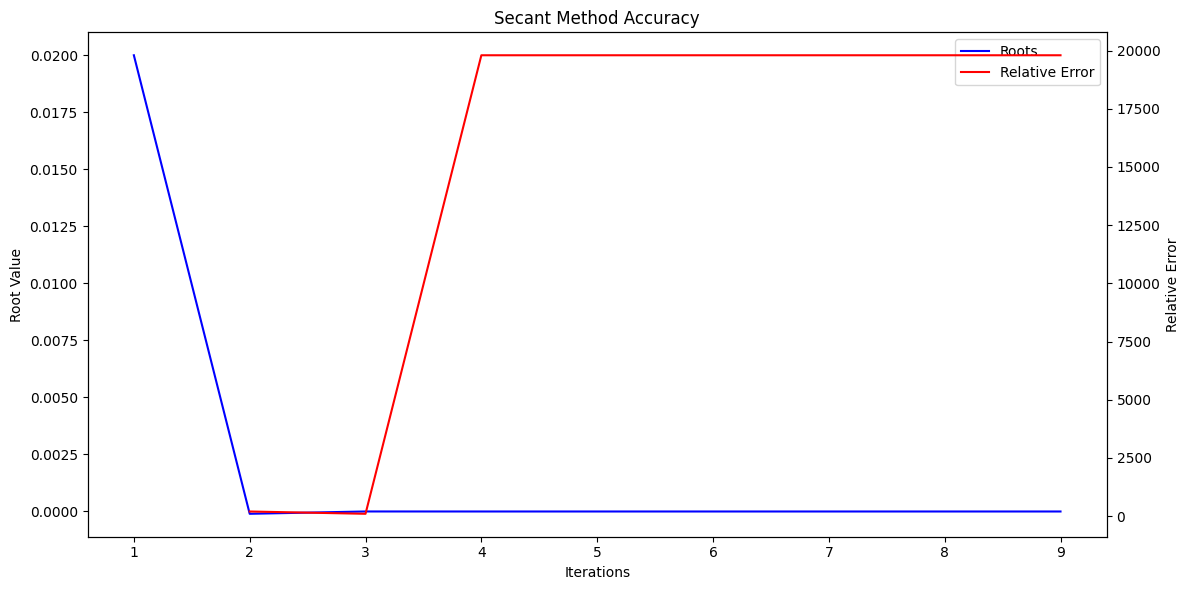

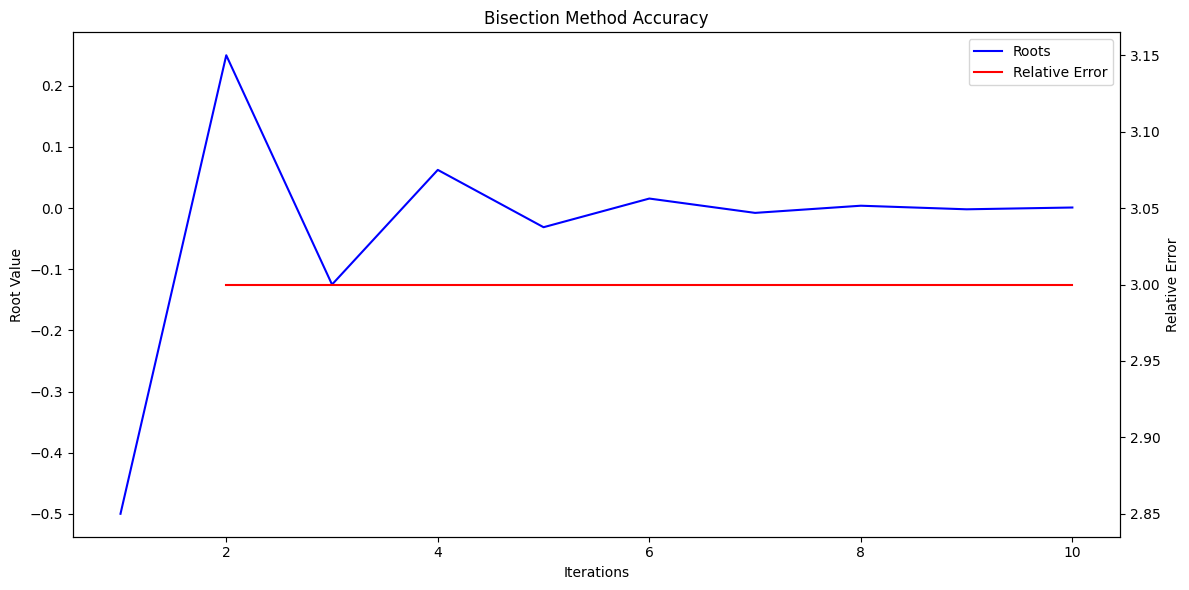

In [58]:
def visualize_secant_method(f, x0, x1, epsilon_rel=1e-6, epsilon_func=1e-6, max_iter=10):
    """
    Visualize the secant method iterations.

    Parameters:
    -----------
    f : function
        Function for which we want to find a root
    x0 : float
        First initial guess
    x1 : float
        Second initial guess
    epsilon_rel : float, optional
        Tolerance for approximate relative error (default: 1e-6)
    epsilon_func : float, optional
        Tolerance for function value (default: 1e-6)
    max_iter : int, optional
        Maximum number of iterations (default: 10)
    """
    roots = []
    iterations = []
    rel_errors = []
    for iter_count in np.arange(1, max_iter):
      root, iters, error = secant_method(f, x0, x1, epsilon_rel, epsilon_func, iter_count)
      roots.append(root)
      iterations.append(iters)
      rel_errors.append(error)

    x_values = np.arange(1, max_iter)
    #root_line = np.arange()

    #Create visualization with two y-axis on one graph
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    ax1.plot(x_values, roots, 'b-',label="Roots")
    ax2.plot(x_values, rel_errors,'r-', label="Relative Error")
    ax1.set_title("Secant Method Accuracy")
    ax1.set_xlabel("Iterations")
    ax1.set_ylabel("Root Value")
    ax2.set_ylabel("Relative Error")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)

    plt.tight_layout()
    plt.show()


def visualize_bisection_method(f, a, b, epsilon_rel=1e-6, epsilon_func=1e-6, max_iter=10):
    """
    Visualize the bisection method iterations.

    Parameters:
    -----------
    f : function
        Function for which we want to find a root
    a : float
        Lower bound of the interval
    b : float
        Upper bound of the interval
    epsilon_rel : float, optional
        Tolerance for approximate relative error (default: 1e-6)
    epsilon_func : float, optional
        Tolerance for function value (default: 1e-6)
    max_iter : int, optional
        Maximum number of iterations (default: 10)
    """
    roots, errors, iterations, rel_error = bisection_method(f, a, b, epsilon_rel=1e-6, epsilon_func=1e-6, max_iter=10, return_list=True)

    x_axis_iterations = range(1, iterations + 1)
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()

    ax1.plot(x_axis_iterations, roots, 'b-',label="Roots")
    ax2.plot(x_axis_iterations, errors,'r-', label="Relative Error")
    ax1.set_title("Bisection Method Accuracy")
    ax1.set_xlabel("Iterations")
    ax1.set_ylabel("Root Value")
    ax2.set_ylabel("Relative Error")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)

    plt.tight_layout()
    plt.show()


# Create visualizations for the challenging function
visualize_secant_method(challenging_function, 0.01, 0.02)
visualize_bisection_method(challenging_function,-2, 1)

# secant_method loop logic debugged and twin-axis visualization structure developed with AI assistance